In [1]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any, Callable, Mapping, Optional, Text, Tuple, Union, Iterable
import numpy as np
import plotly.graph_objects as go
from absl import logging
import utils
import hydra

# plt.style.use('default')
sns.set_theme()


In [2]:
import torch
import wandb
from dm_env import specs

import dmc
import utils
import uuid
from logger import Logger
from replay_buffer import ReplayBufferStorage, make_replay_loader

from video import TrainVideoRecorder, VideoRecorder
from collections import OrderedDict

from modulators import NoisySineModulator

You are using a GLFW raw input patch. This is not the official GLFW library.


/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/bin/../lib/libjpeg.9.dylib' (no su

In [3]:
from hydra.core.global_hydra import GlobalHydra
from omegaconf import DictConfig, OmegaConf

# Clear existing Hydra instance if already initialized
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

# Initialize Hydra and load the config directly
hydra.initialize(config_path="./", version_base=None)
cfg = hydra.compose(config_name="full_train_multitimescale")

In [4]:
domain = "humanoid"

In [5]:
from dmc_benchmark import (
    PRIMAL_TASKS,
    PRIMAL_TASKS_WALK,
    PRIMAL_TASKS_FAST_RUN,
    PRIMAL_TASKS_RUN_BACKWARD,
    CRL_TASKS_SAME_REWARD,
    CRL_TASKS_DIFF_REWARD,
    CRL_DIFF_DYNAMICS_DIFF_REWARD,
    CRL_TASKS_DIFF_RUN_SPEED_REWARD,
    CRL_DIFF_DOMAINS_SAME_REWARD,
    CRL_WALKER_WALK_RUN_TASKS,
    CRL_WALKER_STAND_RUN_TASKS,
    CRL_RUN_JUMP_TASKS,
    CRL_DIFF_DOMAINS_DIFF_REWARD,
    CRL_DIFF_DOMAINS_DIFF_REWARD_CHEETAH_FISH,
)

num_actions = {
    "cheetah": 6,
    "walker": 6,
    "quadruped": 12,
    "cartpole": 1,
    "humanoid": 21,
    "fish": 5,
    "dog": 38,
    "finger": 2,
}

In [6]:
switch_mass_friction_every_n_episodes = 10
mass_modulator_period = 250000
friction_modulator_period = 500000

percentage_shifts_mass = {
    "walker": 0.05,
    "cheetah": 0.05,
    "quadruped": 0.8,
    "humanoid": 0.1,
}
percentage_shifts_friction = {
    "walker": 0,
    "cheetah": 0,
    "quadruped": 0,
    "humanoid": 0,
}

In [7]:
api = wandb.Api()
project_name = "continual_rl" + domain + "_" + cfg.mode
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

summary_list, config_list, name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

num_points_per_task = cfg.num_train_frames / cfg.eval_every_frames
# num_data_points_trained = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.train.num_exposures
# )
# num_data_points_plotting = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.num_exposures
# )

# print("num_data_points_trained: ", num_data_points_trained)
# print("num_data_points_plotting: ", num_data_points_plotting)

for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "capacity_analysis" not in run.tags:
        continue

    if run.config["percentage_shifts_mass"] != percentage_shifts_mass[domain]:
        continue

    print(run.config["agent_name"])

    avg_episode_returns_history = run.scan_history(keys=["eval/episode_reward"])
    avg_episode_reward = [
        row["eval/episode_reward"] for row in avg_episode_returns_history
    ]

    steps_history = run.scan_history(keys=["eval/step"])

    steps = [row["eval/step"] for row in steps_history]

    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue




    print("len(steps): ", len(steps))
    print("len(avg_episode_reward): ", len(avg_episode_reward))

    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.
    temp = dict()
    temp["eval/step"] = steps
    temp["eval/episode_reward"] = avg_episode_reward

    if "attention" in run.config["agent_name"]:
        #attention 1
        # attention_7_history_1 = run.scan_history(keys=["train/attention_distribution1_u_7_mean"])
        # attention_7_1 = [row["train/attention_distribution1_u_7_mean"] for row in attention_7_history_1]
        #
        # attention_6_history_1 = run.scan_history(keys=["train/attention_distribution1_u_6_mean"])
        # attention_6_1 = [row["train/attention_distribution1_u_6_mean"] for row in attention_6_history_1]
        #
        # attention_5_history_1 = run.scan_history(keys=["train/attention_distribution1_u_5_mean"])
        # attention_5_1 = [row["train/attention_distribution1_u_5_mean"] for row in attention_5_history_1]
        #
        # attention_4_history_1 = run.scan_history(keys=["train/attention_distribution1_u_4_mean"])
        # attention_4_1 = [row["train/attention_distribution1_u_4_mean"] for row in attention_4_history_1]

        attention_3_history_1 = run.scan_history(keys=["train/attention_distribution1_u_3_mean"])
        attention_3_1 = [row["train/attention_distribution1_u_3_mean"] for row in attention_3_history_1]

        attention_2_history_1 = run.scan_history(keys=["train/attention_distribution1_u_2_mean"])
        attention_2_1 = [row["train/attention_distribution1_u_2_mean"] for row in attention_2_history_1]

        attention_1_history_1 = run.scan_history(keys=["train/attention_distribution1_u_1_mean"])
        attention_1_1 = [row["train/attention_distribution1_u_1_mean"] for row in attention_1_history_1]

        attention_0_history_1 = run.scan_history(keys=["train/attention_distribution1_u_0_mean"])
        attention_0_1 = [row["train/attention_distribution1_u_0_mean"] for row in attention_0_history_1]

        #attention 2
        # attention_7_history_2 = run.scan_history(keys=["train/attention_distribution2_u_7_mean"])
        # attention_7_2 = [row["train/attention_distribution2_u_7_mean"] for row in attention_7_history_2]
        #
        # attention_6_history_2 = run.scan_history(keys=["train/attention_distribution2_u_6_mean"])
        # attention_6_2 = [row["train/attention_distribution2_u_6_mean"] for row in attention_6_history_2]
        #
        # attention_5_history_2 = run.scan_history(keys=["train/attention_distribution2_u_5_mean"])
        # attention_5_2 = [row["train/attention_distribution2_u_5_mean"] for row in attention_5_history_2]
        #
        # attention_4_history_2 = run.scan_history(keys=["train/attention_distribution2_u_4_mean"])
        # attention_4_2 = [row["train/attention_distribution2_u_4_mean"] for row in attention_4_history_2]

        attention_3_history_2 = run.scan_history(keys=["train/attention_distribution2_u_3_mean"])
        attention_3_2 = [row["train/attention_distribution2_u_3_mean"] for row in attention_3_history_2]

        attention_2_history_2 = run.scan_history(keys=["train/attention_distribution2_u_2_mean"])
        attention_2_2 = [row["train/attention_distribution2_u_2_mean"] for row in attention_2_history_2]

        attention_1_history_2 = run.scan_history(keys=["train/attention_distribution2_u_1_mean"])
        attention_1_2 = [row["train/attention_distribution2_u_1_mean"] for row in attention_1_history_2]

        attention_0_history_2 = run.scan_history(keys=["train/attention_distribution2_u_0_mean"])
        attention_0_2 = [row["train/attention_distribution2_u_0_mean"] for row in attention_0_history_2]

        # attention_7_1.insert(0, 0)
        # attention_6_1.insert(0, 0)
        # attention_5_1.insert(0, 0)
        # attention_4_1.insert(0, 0)
        attention_3_1.insert(0, 0)
        attention_2_1.insert(0, 0)
        attention_1_1.insert(0, 0)
        attention_0_1.insert(0, 0)

        # attention_7_2.insert(0, 0)
        # attention_6_2.insert(0, 0)
        # attention_5_2.insert(0, 0)
        # attention_4_2.insert(0, 0)
        attention_3_2.insert(0, 0)
        attention_2_2.insert(0, 0)
        attention_1_2.insert(0, 0)
        attention_0_2.insert(0, 0)

        # temp["train/attention_distribution1_u_7_mean"] = attention_7_1
        # temp["train/attention_distribution1_u_6_mean"] = attention_6_1
        # temp["train/attention_distribution1_u_5_mean"] = attention_5_1
        # temp["train/attention_distribution1_u_4_mean"] = attention_4_1
        temp["train/attention_distribution1_u_3_mean"] = attention_3_1
        temp["train/attention_distribution1_u_2_mean"] = attention_2_1
        temp["train/attention_distribution1_u_1_mean"] = attention_1_1
        temp["train/attention_distribution1_u_0_mean"] = attention_0_1

        # temp["train/attention_distribution2_u_7_mean"] = attention_7_2
        # temp["train/attention_distribution2_u_6_mean"] = attention_6_2
        # temp["train/attention_distribution2_u_5_mean"] = attention_5_2
        # temp["train/attention_distribution2_u_4_mean"] = attention_4_2
        temp["train/attention_distribution2_u_3_mean"] = attention_3_2
        temp["train/attention_distribution2_u_2_mean"] = attention_2_2
        temp["train/attention_distribution2_u_1_mean"] = attention_1_2
        temp["train/attention_distribution2_u_0_mean"] = attention_0_2

    else:
        zeros_list = [0] * len(steps)
        # temp["train/attention_distribution1_u_7_mean"] = zeros_list
        # temp["train/attention_distribution1_u_6_mean"] = zeros_list
        # temp["train/attention_distribution1_u_5_mean"] = zeros_list
        # temp["train/attention_distribution1_u_4_mean"] = zeros_list
        temp["train/attention_distribution1_u_3_mean"] = zeros_list
        temp["train/attention_distribution1_u_2_mean"] = zeros_list
        temp["train/attention_distribution1_u_1_mean"] = zeros_list
        temp["train/attention_distribution1_u_0_mean"] = zeros_list

        # temp["train/attention_distribution2_u_7_mean"] = zeros_list
        # temp["train/attention_distribution2_u_6_mean"] = zeros_list
        # temp["train/attention_distribution2_u_5_mean"] = zeros_list
        # temp["train/attention_distribution2_u_4_mean"] = zeros_list
        temp["train/attention_distribution2_u_3_mean"] = zeros_list
        temp["train/attention_distribution2_u_2_mean"] = zeros_list
        temp["train/attention_distribution2_u_1_mean"] = zeros_list
        temp["train/attention_distribution2_u_0_mean"] = zeros_list

    print("len attention_0_1: ", len(temp["train/attention_distribution1_u_0_mean"]))

    summary_list.append(temp)
    del temp

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    name_list.append(run.name)

num_of_runs: 511
idx: 0
idx: 10
idx: 20
idx: 30
idx: 40
ddpg
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
idx: 50
idx: 60
ddpg_beakers_params_continuous
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg_beakers_params_continuous
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg_beakers_params_continuous
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg_beakers_params_continuous
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg_beakers_params_continuous
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
idx: 70
sf_simple_beakers_params
len(s

In [8]:
runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

# create a new column using agent_name
runs_df["agent_name"] = runs_df["config"].apply(lambda x: x["agent_name"])

# # create a new column using agents_seed
runs_df["agent_seed"] = runs_df["config"].apply(lambda x: x["seed"])

In [9]:
agents_new_names = {
    "ddpg": "TD3",
    "ddpg_beakers_params_continuous": "TD3 + SC",
    "sf_simple": "SF",
    "sf_simple_beakers_params": "SF + SC (Ours)",
    "ddpg_plasticity_injection_last_layer": "TD3 + P-last",
    "ddpg_online_ewc": "TD3 + EWC",
    "sf_online_ewc": "SF + EWC",
    "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention (Ours)",
    "ddpg_plasticity_injection": "TD3 + Plasticity (last few layers)",
    "ddpg_continual_backprop": "TD3 + CBP",
    "ddpg_capacity_scaled": "TD3 (small)",
    "ddpg_cbp_capacity_scaled": "TD3 + CBP (small)",
    "ddpg_online_ewc_capacity_scaled": "TD3 + EWC (small)",
    "ddpg_plasticity_injection_last_layer_capacity_scaled": "TD3 + P-last (small)",
    "ddpg_beakers_params_continuous_capacity_scaled": "TD3 + SC (small)",
}

In [10]:
# replace all "ddpg" in agent_name column with "TD3"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg", agents_new_names["ddpg"]
)

In [11]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple", agents_new_names["sf_simple"]
)

In [12]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_beakers_params_continuous", agents_new_names["ddpg_beakers_params_continuous"]
)

In [13]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params", agents_new_names["sf_simple_beakers_params"]
)

In [14]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection", agents_new_names["ddpg_plasticity_injection"]
)

In [15]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection_last_layer", agents_new_names["ddpg_plasticity_injection_last_layer"]
)

In [16]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_online_ewc", agents_new_names["ddpg_online_ewc"]
)

In [17]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_online_ewc", agents_new_names["sf_online_ewc"]
)

In [18]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params_continuous_attention_diff_unique", agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]
)

In [19]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_continual_backprop", agents_new_names["ddpg_continual_backprop"]
)

In [20]:
# replace all "ddpg" in agent_name column with "TD3"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_capacity_scaled", agents_new_names["ddpg_capacity_scaled"]
)

In [21]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_beakers_params_continuous_capacity_scaled", agents_new_names["ddpg_beakers_params_continuous_capacity_scaled"]
)

In [22]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection_last_layer_capacity_scaled", agents_new_names["ddpg_plasticity_injection_last_layer_capacity_scaled"]
)

In [23]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_online_ewc_capacity_scaled", agents_new_names["ddpg_online_ewc_capacity_scaled"]
)

In [24]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_cbp_capacity_scaled", agents_new_names["ddpg_cbp_capacity_scaled"]
)

In [25]:
# print unique agent_name
print(runs_df["agent_name"].unique())


['TD3' 'TD3 + SC' 'SF + SC (Ours)' 'SF' 'SF + EWC' 'TD3 + EWC' 'TD3 + CBP'
 'TD3 + P-last' 'TD3 + SC (small)' 'TD3 + CBP (small)' 'TD3 (small)'
 'TD3 + EWC (small)' 'TD3 + P-last (small)']


In [26]:
print(runs_df)

                                              summary  \
0   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
1   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
2   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
3   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
4   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
..                                                ...   
70  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
71  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
72  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
73  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
74  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   

                                               config  \
0   {'mode': 'full_train_run_forward', 'seed': 679...   
1   {'mode': 'full_train_run_forward', 'seed': 582...   
2   {'mode': 'full_train_run_forward', 'seed': 291...   
3   {'mode': 'full_train_run_forward', 'seed': 388...   
4   {'mode': 'full_train_run_f

In [27]:
print(runs_df.columns.tolist())

['summary', 'config', 'name', 'agent_name', 'agent_seed']


In [28]:
print("runs_df shape:", runs_df.shape)

runs_df shape: (75, 5)


In [29]:
# remove the name and config column
runs_df = runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
runs_df = pd.concat(
    [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
)

# reset index
runs_df = runs_df.reset_index(drop=True)

print(runs_df)

# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row
runs_df = runs_df.explode(list(runs_df.columns[2:])).reset_index(drop=True)

# apply rolling mean to the column train/episode_reward
# runs_df["train/episode_reward"] = runs_df["train/episode_reward"].rolling(
#     window=cfg.plotting.moving_average_window, min_periods=1
# ).mean()

print(runs_df.shape)

print("dataframe: ", runs_df)

              agent_name  agent_seed  \
0                    TD3         679   
1                    TD3         582   
2                    TD3         291   
3                    TD3         388   
4                    TD3         485   
..                   ...         ...   
70  TD3 + P-last (small)         291   
71  TD3 + P-last (small)         388   
72  TD3 + P-last (small)         485   
73  TD3 + P-last (small)         582   
74  TD3 + P-last (small)         679   

                                            eval/step  \
0   [0, 10000, 20000, 30000, 40000, 50000, 60000, ...   
1   [0, 10000, 20000, 30000, 40000, 50000, 60000, ...   
2   [0, 10000, 20000, 30000, 40000, 50000, 60000, ...   
3   [0, 10000, 20000, 30000, 40000, 50000, 60000, ...   
4   [0, 10000, 20000, 30000, 40000, 50000, 60000, ...   
..                                                ...   
70  [0, 10000, 20000, 30000, 40000, 50000, 60000, ...   
71  [0, 10000, 20000, 30000, 40000, 50000, 60000, ...   
72  [0

In [30]:
color_code = {
    "TD3": "#1f77b4",
    "SF": "#ff7f0e",
    "TD3 + SC": "#2ca02c",
    "SF + SC (Ours)": "#9467bd",
    "SF + SC": "#9467bd",
    "TD3 + P-last": "#ffbb00",
    "TD3 + Plasticity (last few layers)": "#d62728",
    "SF + SC + Attention": "#8B4513",
    "SF + SC + Attention (Ours)": "#8B4513",
    "TD3\n +SC": "#2ca02c",
    "SF\n +SC (Ours)": "#9467bd",
    "SF\n +SC \n(Ours)": "#9467bd",
    "SF\n +SC": "#9467bd",
    "SF\n +SC\n +Attention (Ours)": "#8B4513",
    "SF\n +SC\n +Attention": "#8B4513",
    "SF + EWC": "#e377c2",
    "TD3 + EWC": "#bcbd22",
    "SF\n +EWC": "#e377c2",
    "TD3\n +EWC": "#bcbd22",
    "TD3 + CBP": "#d62728",
    "TD3\n +CBP": "#d62728",
    "TD3\n +P-last": "#ffbb00",
    "TD3 (small)": "#1f77b4",
    "TD3 + SC (small)": "#2ca02c",
    "TD3 + P-last (small)": "#ffbb00",
    "TD3 + CBP (small)": "#d62728",
    "TD3 + EWC (small)": "#bcbd22",
    # "SF + SC": "#ff7f0e",
    # "TD3 + SC": "#2ca02c",
    # "SF + SC": "#d62728",
    # "SF + Random": "#2ca02c",
    # "SF + Reconstruction": "#d62728",
    # "SF + Laplacian": "#9467bd",
    # "APS (Pre-train)": "#8c564b",
    # "Canonical-SF": "#e377c2",
    # "SF + Q-TD + Reward": "#bcbd22",
    # "SF simple + SC": "#2ca02c",
    # "SF simple + Task SC": "#d62728",
    # "SF simple + SC & Task SC": "#9467bd",
    # "DQN + SC": "#8c564b",
}

# agents_new_names = {
#     "ddpg": "TD3",
#     "ddpg_beakers_params_continuous": "TD3 + SC",
#     "sf_simple": "SF",
#     "sf_simple_beakers_params": "SF + SC",
#     "ddpg_plasticity_injection_last_layer": "TD3 + Plasticity (last layer)",
#     "ddpg_online_ewc": "TD3 (EWC)",
#     "sf_online_ewc": "SF (EWC)",
#     "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention",
#     "ddpg_plasticity_injection": "TD3 + Plasticity",
# }

In [31]:
param_dict = {
    "TD3": 3_341_326,
    "SF": 1_313_844,
    "SF + EWC": 1_313_844,
    "SF + SC (Ours)": 2_583_844,
    "TD3\n +SC": 20_913_182,
    "TD3 + SC": 20_913_182,
    "TD3 + P-last": 3_341_326,
    "TD3\n +EWC": 3_341_326,
    "TD3 + EWC": 3_341_326,
    "TD3 + CBP": 3_341_326,
    "TD3\n +CBP": 3_341_326,
    "TD3\n +P-last": 3_341_326,
    "TD3 (small)": 2_546_304,
    "TD3 + SC (small)": 2_546_304,
    "TD3 + CBP (small)": 2_546_304,
    "TD3 + EWC (small)": 2_546_304,
    "TD3 + P-last (small)": 2_546_304,
}

# Add new column
runs_df["num_params"] = runs_df["agent_name"].map(param_dict)

In [32]:
# runs_df["eval/cumulative_episode_reward"] = runs_df["eval/episode_reward"].cumsum()

print(runs_df.columns)

runs_df["eval/episode_rewards_num"] = (
    runs_df["eval/episode_reward"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

runs_df = runs_df.sort_values(["agent_name", "agent_seed", "eval/step"])

runs_df["eval/cumulative_rewards"] = (
    runs_df.groupby(["agent_name", "agent_seed"])["eval/episode_rewards_num"].cumsum()
)

runs_df["episode_count"] = (
    runs_df.groupby(["agent_name", "agent_seed"]).cumcount() + 1
)

runs_df["norm_cum_reward"] = runs_df["eval/cumulative_rewards"] / runs_df["episode_count"]

runs_df["agent_name_pretty"] = runs_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(runs_df.columns)

Index(['agent_name', 'agent_seed', 'eval/step', 'eval/episode_reward',
       'train/attention_distribution1_u_3_mean',
       'train/attention_distribution1_u_2_mean',
       'train/attention_distribution1_u_1_mean',
       'train/attention_distribution1_u_0_mean',
       'train/attention_distribution2_u_3_mean',
       'train/attention_distribution2_u_2_mean',
       'train/attention_distribution2_u_1_mean',
       'train/attention_distribution2_u_0_mean', 'num_params'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'eval/step', 'eval/episode_reward',
       'train/attention_distribution1_u_3_mean',
       'train/attention_distribution1_u_2_mean',
       'train/attention_distribution1_u_1_mean',
       'train/attention_distribution1_u_0_mean',
       'train/attention_distribution2_u_3_mean',
       'train/attention_distribution2_u_2_mean',
       'train/attention_distribution2_u_1_mean',
       'train/attention_distribution2_u_0_mean', 'num_params',
       'eval/episode_re

In [33]:
print(runs_df)

             agent_name  agent_seed  eval/step eval/episode_reward  \
5700                 SF          97          0            1.081231   
5701                 SF          97      10000            0.950845   
5702                 SF          97      20000            1.661242   
5703                 SF          97      30000            0.947591   
5704                 SF          97      40000            1.493669   
...                 ...         ...        ...                 ...   
14095  TD3 + SC (small)         485  2950000.0          407.684845   
14096  TD3 + SC (small)         485  2960000.0          404.756929   
14097  TD3 + SC (small)         485  2970000.0          459.168504   
14098  TD3 + SC (small)         485  2980000.0          485.244111   
14099  TD3 + SC (small)         485  2990000.0          478.984322   

      train/attention_distribution1_u_3_mean  \
5700                                       0   
5701                                       0   
5702           

In [34]:
print(runs_df[runs_df["num_params"].isna()])

Empty DataFrame
Columns: [agent_name, agent_seed, eval/step, eval/episode_reward, train/attention_distribution1_u_3_mean, train/attention_distribution1_u_2_mean, train/attention_distribution1_u_1_mean, train/attention_distribution1_u_0_mean, train/attention_distribution2_u_3_mean, train/attention_distribution2_u_2_mean, train/attention_distribution2_u_1_mean, train/attention_distribution2_u_0_mean, num_params, eval/episode_rewards_num, eval/cumulative_rewards, episode_count, norm_cum_reward, agent_name_pretty]
Index: []


              agent_name  num_params      mean_AUC       std_AUC  n  \
0                     SF     1313844  3.004897e+08  2.994283e+08  5   
1               SF + EWC     1313844  8.873627e+06  4.559035e+06  5   
2         SF + SC (Ours)     2583844  7.238499e+08  2.474361e+08  5   
3                    TD3     3341326  6.339247e+08  1.167448e+08  5   
4            TD3 (small)     2546304  5.079812e+08  3.686620e+08  7   
5              TD3 + CBP     3341326  7.043185e+06  1.565440e+06  7   
6      TD3 + CBP (small)     2546304  7.093146e+06  2.619645e+06  7   
7              TD3 + EWC     3341326  5.338655e+08  1.905944e+08  5   
8      TD3 + EWC (small)     2546304  4.853022e+08  2.675391e+08  7   
9           TD3 + P-last     3341326  1.355816e+08  1.758293e+08  5   
10  TD3 + P-last (small)     2546304  2.080712e+08  1.855375e+08  7   
11              TD3 + SC    20913182  6.714469e+08  1.373159e+08  5   
12      TD3 + SC (small)     2546304  6.204510e+08  3.513514e+08  5   

     

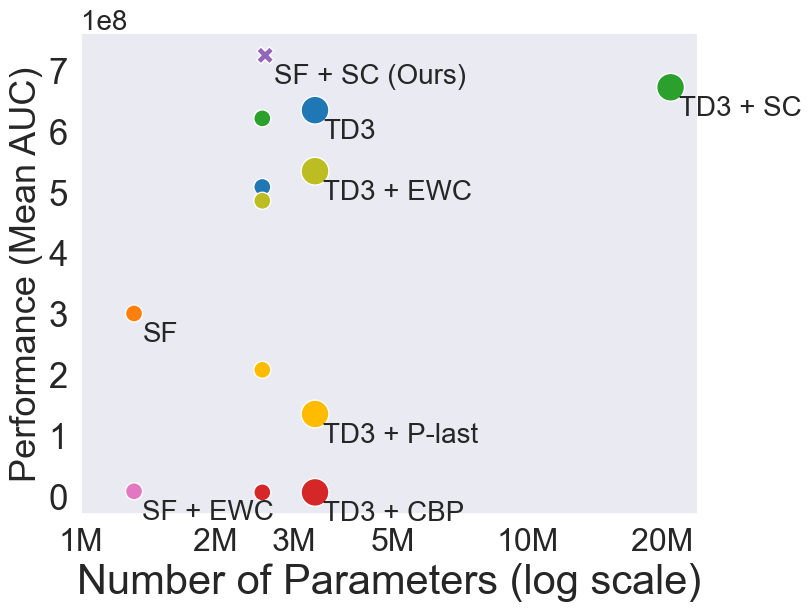

In [35]:
from scipy.integrate import trapezoid
from adjustText import adjust_text
from matplotlib.ticker import LogLocator, NullFormatter

colors = sns.color_palette("colorblind", 3)
plt.figure(figsize=(8,6), constrained_layout=True)

def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)


auc_df["num_params"] = auc_df["agent_name"].map(param_dict)


# Group by agent
df_mean = (
    auc_df
    .groupby(["agent_name", "num_params"], as_index=False)
    .agg(
        mean_AUC=("AUC", "mean"),
        std_AUC=("AUC", "std"),
        n=("AUC", "count")
    )
)

# Optional: compute standard error
df_mean["sem_AUC"] = df_mean["std_AUC"] / (df_mean["n"] ** 0.5)

df_mean["is_small_or_sf"] = df_mean["agent_name"].str.contains(
    r"small|SF",
    case=False,   # ignore capitalization
    regex=True
)
df_mean["point_size"] = df_mean["is_small_or_sf"].map({
    True: 150,     # small models
    False: 400    # larger models
})
print(df_mean)
print(df_mean["agent_name"].unique())

df_mean["marker_type"] = df_mean["agent_name"].apply(
    lambda x: "star" if x == "SF + SC (Ours)" else "circle"
)

marker_map = {
    "circle": "o",
    "star": "*"
}

ax = sns.scatterplot(
    data=df_mean,
    x="num_params",
    y="mean_AUC",
    size="point_size",
    sizes=(150, 400),
    palette=color_code,
    hue="agent_name",
    legend=False,
    style="marker_type",
)

plt.xscale("log")

# Label models
# for i in range(len(df_mean)):
#     plt.annotate(
#         df_mean["agent_name"][i],
#         xy=(df_mean["num_params"][i], df_mean["mean_AUC"][i]),
#         xytext=(6, -6),              # (right, down) in pixels
#         textcoords="offset points",
#         ha="left",                   # anchor left edge
#         va="top"                     # anchor top edge (so text goes downward)
#     )

for i in range(len(df_mean)):
    name = df_mean["agent_name"][i]

    # Skip labels that contain "(small)"
    if "(small)" in name:
        continue

    ax.annotate(
        name,
        xy=(df_mean["num_params"][i], df_mean["mean_AUC"][i]),
        xytext=(6, -6),
        textcoords="offset points",
        ha="left",
        va="top",
        fontsize=20
    )

sns.despine()

plt.xticks(
    [1e6, 2e6, 3e6, 5e6, 1e7, 2e7],
    ["1M", "2M", "3M", "5M", "10M", "20M"]
)
# Hide minor tick labels (keep marks only)
ax.xaxis.set_minor_formatter(NullFormatter())
plt.xlabel("Number of Parameters (log scale)", fontsize=30)
plt.ylabel("Performance (Mean AUC)", fontsize=26)
plt.gca().yaxis.get_offset_text().set_fontsize(20)

plt.xticks(fontsize=23)
plt.yticks(fontsize=25)
plt.grid(False)
# plt.tight_layout()
filename = "num_params_vs_performance_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


        agent_name  num_params      mean_AUC       std_AUC  n
0               SF     1313844  3.004897e+08  2.994283e+08  5
1         SF + EWC     1313844  8.873627e+06  4.559035e+06  5
2   SF + SC (Ours)     2583844  7.238499e+08  2.474361e+08  5
3              TD3     3341326  6.339247e+08  1.167448e+08  5
5        TD3 + CBP     3341326  7.043185e+06  1.565440e+06  7
7        TD3 + EWC     3341326  5.338655e+08  1.905944e+08  5
9     TD3 + P-last     3341326  1.355816e+08  1.758293e+08  5
11        TD3 + SC    20913182  6.714469e+08  1.373159e+08  5
['SF' 'SF + EWC' 'SF + SC (Ours)' 'TD3' 'TD3 + CBP' 'TD3 + EWC'
 'TD3 + P-last' 'TD3 + SC']
names:  0                SF
1          SF + EWC
2    SF + SC (Ours)
3               TD3
4         TD3 + CBP
5         TD3 + EWC
6      TD3 + P-last
7          TD3 + SC
Name: agent_name, dtype: object


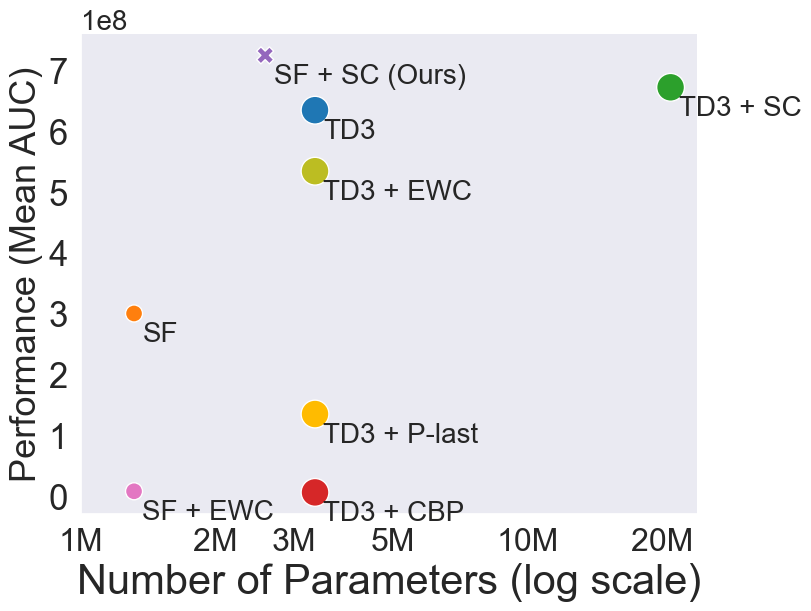

In [36]:
colors = sns.color_palette("colorblind", 3)
plt.figure(figsize=(8,6), constrained_layout=True)

def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)


auc_df["num_params"] = auc_df["agent_name"].map(param_dict)


# Group by agent
df_mean = (
    auc_df
    .groupby(["agent_name", "num_params"], as_index=False)
    .agg(
        mean_AUC=("AUC", "mean"),
        std_AUC=("AUC", "std"),
        n=("AUC", "count")
    )
)

# remove rows where the "(small)" is in "agent_name"
df_mean_small_removed = df_mean[~df_mean["agent_name"].str.contains(r"\(small\)", regex=True)].copy()

print(df_mean_small_removed)
print(df_mean_small_removed["agent_name"].unique())

# Reset index so rows are 0..N-1 (helps annotation loops and avoids confusing old indices)
df_mean_small_removed.reset_index(drop=True, inplace=True)

# Optional: compute standard error
df_mean_small_removed["sem_AUC"] = df_mean_small_removed["std_AUC"] / (df_mean_small_removed["n"] ** 0.5)

df_mean_small_removed["is_small_or_sf"] = df_mean_small_removed["agent_name"].str.contains(
    r"small|SF",
    case=False,   # ignore capitalization
    regex=True
)
df_mean_small_removed["point_size"] = df_mean_small_removed["is_small_or_sf"].map({
    True: 150,     # small models
    False: 400    # larger models
})

df_mean_small_removed["marker_type"] = df_mean_small_removed["agent_name"].apply(
    lambda x: "star" if x == "SF + SC (Ours)" else "circle"
)



marker_map = {
    "circle": "o",
    "star": "*"
}

ax = sns.scatterplot(
    data=df_mean_small_removed,
    x="num_params",
    y="mean_AUC",
    size="point_size",
    sizes=(150, 400),
    palette=color_code,
    hue="agent_name",
    legend=False,
    style="marker_type",
)

plt.xscale("log")

# Label models
# for i in range(len(df_mean)):
#     plt.annotate(
#         df_mean["agent_name"][i],
#         xy=(df_mean["num_params"][i], df_mean["mean_AUC"][i]),
#         xytext=(6, -6),              # (right, down) in pixels
#         textcoords="offset points",
#         ha="left",                   # anchor left edge
#         va="top"                     # anchor top edge (so text goes downward)
#     )
print("names: ", df_mean_small_removed["agent_name"])
for i in range(len(df_mean_small_removed)):
    name = df_mean_small_removed["agent_name"][i]

    ax.annotate(
        name,
        xy=(df_mean_small_removed["num_params"][i], df_mean_small_removed["mean_AUC"][i]),
        xytext=(6, -6),
        textcoords="offset points",
        ha="left",
        va="top",
        fontsize=20
    )

sns.despine()

plt.xticks(
    [1e6, 2e6, 3e6, 5e6, 1e7, 2e7],
    ["1M", "2M", "3M", "5M", "10M", "20M"]
)
# Hide minor tick labels (keep marks only)
ax.xaxis.set_minor_formatter(NullFormatter())
plt.xlabel("Number of Parameters (log scale)", fontsize=30)
plt.ylabel("Performance (Mean AUC)", fontsize=26)
plt.gca().yaxis.get_offset_text().set_fontsize(20)


plt.xticks(fontsize=23)
plt.yticks(fontsize=25)
plt.grid(False)
# plt.tight_layout()
filename = "original_num_params_vs_performance_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


In [37]:
df_mean_small_removed["agent_name"]

0                SF
1          SF + EWC
2    SF + SC (Ours)
3               TD3
4         TD3 + CBP
5         TD3 + EWC
6      TD3 + P-last
7          TD3 + SC
Name: agent_name, dtype: object